<a href="https://colab.research.google.com/github/Siddhant-W/medical-misinformation-nlp/blob/main/M_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/kinit-sk/medical-misinformation-dataset

fatal: destination path 'medical-misinformation-dataset' already exists and is not an empty directory.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
import os

for root, dirs, files in os.walk("/content/medical-misinformation-dataset"):
    for file in files:
        print(os.path.join(root, file))

/content/medical-misinformation-dataset/requirements.txt
/content/medical-misinformation-dataset/monant-medical-misinformation-dataset_descriptive-analysis_rest-api.ipynb
/content/medical-misinformation-dataset/monant-medical-misinformation-dataset_descriptive-analysis_csv-dump.ipynb
/content/medical-misinformation-dataset/README.md
/content/medical-misinformation-dataset/.gitignore
/content/medical-misinformation-dataset/.git/packed-refs
/content/medical-misinformation-dataset/.git/index
/content/medical-misinformation-dataset/.git/description
/content/medical-misinformation-dataset/.git/HEAD
/content/medical-misinformation-dataset/.git/config
/content/medical-misinformation-dataset/.git/info/exclude
/content/medical-misinformation-dataset/.git/refs/remotes/origin/HEAD
/content/medical-misinformation-dataset/.git/refs/heads/main
/content/medical-misinformation-dataset/.git/objects/pack/pack-d0c866456c416e2c15ee21b28d25593026a6af3c.idx
/content/medical-misinformation-dataset/.git/objec

In [ ]:
df = pd.read_csv("/content/medical-misinformation-dataset/sample_data/claims.csv")
df.head()

,id,name,statement,description,category,rating,queries,created_at,updated_at
0,6771,NaN,Dawn dish soap contains ammonia even though it...,Could Mixing Dawn Dish Soap with Clorox Bleach...,"{medical,science}",mixture,NaN,2020-06-28 21:40:18.799231+02,2020-06-28 21:40:18.799231+02
1,2468,NaN,Is blue light harmful to our eyes?,<p>It seems reasonable to reduce exposure to b...,{medical},unknown,NaN,2019-12-13 14:31:00.722277+01,2022-03-15 13:29:08.784596+01
2,1929,NaN,Are the 'Winter Blues' real?,"<p>I've recently <a href=""https://www.scienced...",{medical},true,NaN,2019-12-13 14:29:45.612355+01,2022-03-07 13:14:05.890931+01
3,1872,NaN,Is air pollution linked to greater risk of dem...,"<p><a href=""https://www.theguardian.com/enviro...",{medical},true,NaN,2019-12-13 14:29:38.661545+01,2022-03-05 13:04:03.269382+01
4,1956,NaN,Can eccentric exercises cause human hyperplasia?,<p>With concentric regular exercises muscle hy...,{medical},unknown,NaN,2019-12-13 14:29:48.995208+01,2022-03-15 13:28:44.097366+01


In [ ]:
print(df.columns)
print(df.head())
print(df.isnull().sum())

Index(['id', 'name', 'statement', 'description', 'category', 'rating',
       'queries', 'created_at', 'updated_at'],
      dtype='object')
     id name                                          statement  \
0  6771  NaN  Dawn dish soap contains ammonia even though it...   
1  2468  NaN                 Is blue light harmful to our eyes?   
2  1929  NaN                       Are the 'Winter Blues' real?   
3  1872  NaN  Is air pollution linked to greater risk of dem...   
4  1956  NaN   Can eccentric exercises cause human hyperplasia?   

                                         description           category  \
0  Could Mixing Dawn Dish Soap with Clorox Bleach...  {medical,science}   
1  <p>It seems reasonable to reduce exposure to b...          {medical}   
2  <p>I've recently <a href="https://www.scienced...          {medical}   
3  <p><a href="https://www.theguardian.com/enviro...          {medical}   
4  <p>With concentric regular exercises muscle hy...          {medical}   

    ra

In [ ]:
# CHANGE these names based on dataset
df = df.rename(columns={"statement": "claim", "rating": "label"})
df.head()

,id,name,claim,description,category,label,queries,created_at,updated_at
0,6771,NaN,Dawn dish soap contains ammonia even though it...,Could Mixing Dawn Dish Soap with Clorox Bleach...,"{medical,science}",mixture,NaN,2020-06-28 21:40:18.799231+02,2020-06-28 21:40:18.799231+02
1,2468,NaN,Is blue light harmful to our eyes?,<p>It seems reasonable to reduce exposure to b...,{medical},unknown,NaN,2019-12-13 14:31:00.722277+01,2022-03-15 13:29:08.784596+01
2,1929,NaN,Are the 'Winter Blues' real?,"<p>I've recently <a href=""https://www.scienced...",{medical},true,NaN,2019-12-13 14:29:45.612355+01,2022-03-07 13:14:05.890931+01
3,1872,NaN,Is air pollution linked to greater risk of dem...,"<p><a href=""https://www.theguardian.com/enviro...",{medical},true,NaN,2019-12-13 14:29:38.661545+01,2022-03-05 13:04:03.269382+01
4,1956,NaN,Can eccentric exercises cause human hyperplasia?,<p>With concentric regular exercises muscle hy...,{medical},unknown,NaN,2019-12-13 14:29:48.995208+01,2022-03-15 13:28:44.097366+01


In [ ]:
df = df[['claim', 'label']].dropna()

df['label'] = df['label'].astype(str).str.lower()

print(df['label'].value_counts())

label
false           349
unknown         202
true             56
mostly-true      19
mixture          18
mostly-false     13
Name: count, dtype: int64


In [ ]:
df['label'] = df['label'].map({
    'true': 1,
    'false': 0,
    'misleading': 0
})

df = df.dropna()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['claim'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train)

y_pred_lr = model.predict(X_test_vec)

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Results:

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95        74
         1.0       0.00      0.00      0.00         7

    accuracy                           0.91        81
   macro avg       0.46      0.50      0.48        81
weighted avg       0.83      0.91      0.87        81

Accuracy: 0.9135802469135802


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


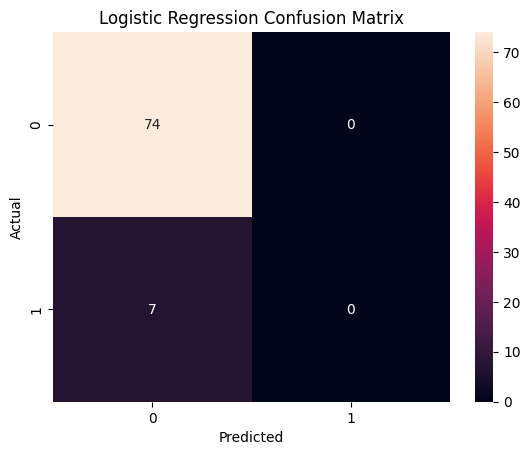

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
!pip install transformers

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
bert_preds = []

for text in X_test[:100]:
    result = classifier(str(text))
    label = result[0]['label']

    if label == 'POSITIVE':
        bert_preds.append(1)
    else:
        bert_preds.append(0)

In [ ]:
y_test_subset = y_test[:100]

print("BERT Results:\n")
print(classification_report(y_test_subset, bert_preds))
print("Accuracy:", accuracy_score(y_test_subset, bert_preds))

BERT Results:

              precision    recall  f1-score   support

         0.0       0.91      0.84      0.87        74
         1.0       0.08      0.14      0.10         7

    accuracy                           0.78        81
   macro avg       0.49      0.49      0.49        81
weighted avg       0.84      0.78      0.81        81

Accuracy: 0.7777777777777778


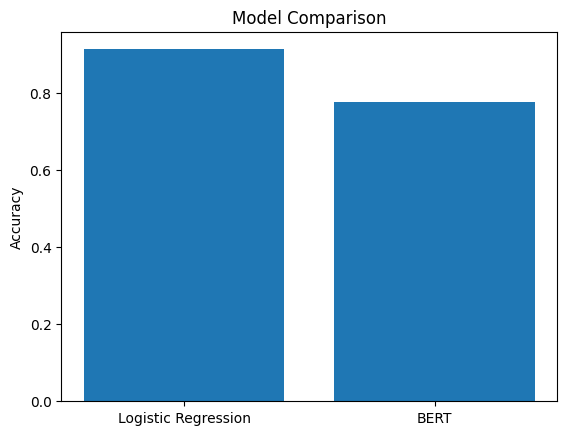

In [ ]:
lr_acc = accuracy_score(y_test, y_pred_lr)
bert_acc = accuracy_score(y_test_subset, bert_preds)

models = ['Logistic Regression', 'BERT']
accuracy = [lr_acc, bert_acc]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
sample = "Drinking hot water cures COVID-19"

print("Logistic Regression Prediction:")
print(model.predict(vectorizer.transform([sample])))

print("\nBERT Prediction:")
print(classifier(sample))

Logistic Regression Prediction:
[0.]

BERT Prediction:
[{'label': 'POSITIVE', 'score': 0.5230496525764465}]
